# Release metro plan

Combined directed dependency diagram and release plan. Repositories are arranged in wave columns from left to right, with directed edges showing the dependency flow between them.

In [10]:
repository_filter: list[str] = []
data_file_dependencies: str = "../samples/release_metro_dependencies_in_use.csv"
data_file_parents: str = "../samples/release_metro_parent_relationships.csv"

In [11]:
import pandas as pd
import plotly.graph_objects as go
from code_data_science import data_table as dt
from moderne_visualizations_misc.reusable.release_metro_utils import (
    build_release_graph,
    compute_release_waves,
    cubic_bezier,
)
from moderne_visualizations_misc.reusable.quality_utils import (
    filter_repos,
    short_repo,
    empty_figure,
)
import warnings

warnings.simplefilter("ignore")

coords_df = dt.read_csv("../samples/project_coordinates.csv")
deps_df = pd.read_csv(data_file_dependencies, on_bad_lines="skip")
parents_df = pd.read_csv(data_file_parents, on_bad_lines="skip")

coords_df = filter_repos(coords_df, repository_filter)
deps_df = filter_repos(deps_df, repository_filter)
parents_df = filter_repos(parents_df, repository_filter)

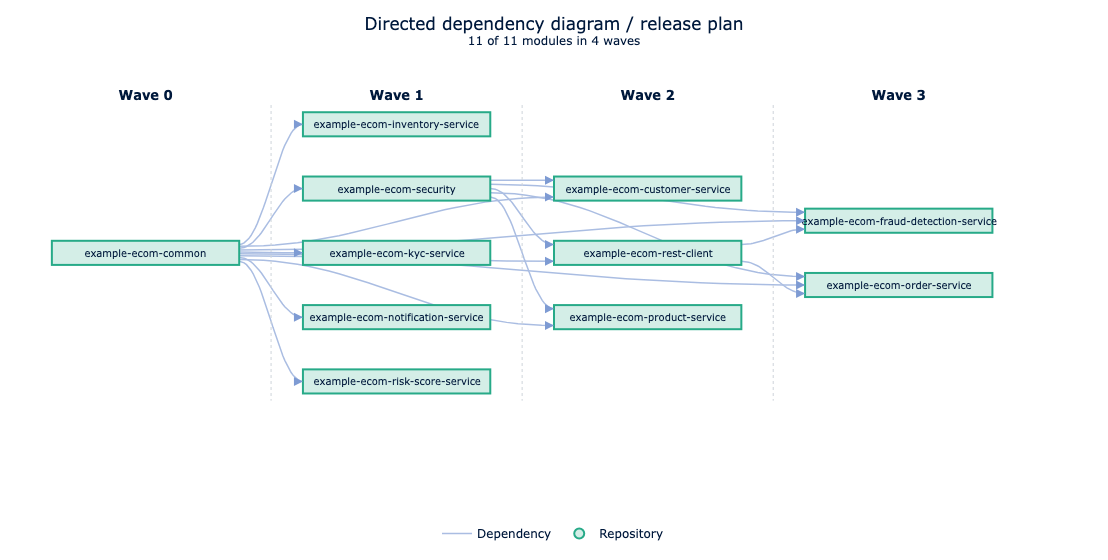

In [12]:
import code_data_science.palette as palette
from collections import defaultdict

# Moderne brand colors
_cm = palette.__moderne_color_map
GREEN = _cm["activity_green"][500]
GREEN_LIGHT = _cm["activity_green"][100]
RED = _cm["cherry_red"][500]
RED_LIGHT = _cm["cherry_red"][100]
INDIGO = _cm["indigo"]["main"]
GREY_400 = _cm["grey"][400]
PERIWINKLE = _cm["periwinkle"][500]
MAGENTA = _cm["magenta"][500]

# Pixel constants for layout sizing
_CHAR_PX = 7.5     # avg char width at font-size 10
_BOX_PAD_PX = 24   # horizontal padding inside box
_GAP_PX = 100      # horizontal gap between columns for curves
_ROW_H_PX = 30     # box height in pixels
_ROW_GAP_PX = 50   # vertical gap between rows


if len(coords_df) == 0:
    fig = empty_figure("No project coordinate data found.")
else:
    G = build_release_graph(coords_df, deps_df, parents_df)
    waves, circular = compute_release_waves(G)

    total_modules = len(G.nodes())
    releasable = sum(len(w) for w in waves)
    wave_count = len(waves)

    # --- Build columns ---
    node_is_circular: set[str] = set(circular)
    all_columns: list[tuple[str, list[str]]] = []
    for i, wave in enumerate(waves):
        all_columns.append((f"Wave {i}", wave))
    if circular:
        last_wave_idx = len(waves) - 1
        all_columns[-1] = (f"Wave {last_wave_idx} + C", all_columns[-1][1])
        all_columns.append(("Circular", circular))

    # --- Layout in pixel coordinates (1 data unit = 1 pixel) ---
    all_labels = {repo: short_repo(repo) for repo in G.nodes()}
    max_label_len = max((len(lbl) for lbl in all_labels.values()), default=10)
    box_w_px = max_label_len * _CHAR_PX + _BOX_PAD_PX
    hw = box_w_px / 2
    hh = _ROW_H_PX / 2
    col_step = box_w_px + _GAP_PX
    row_step = _ROW_H_PX + _ROW_GAP_PX

    max_col_height = max((len(col[1]) for col in all_columns), default=1)

    # Figure pixel dimensions
    fig_w = int(len(all_columns) * col_step + _GAP_PX)
    fig_h = max(400, int(max_col_height * row_step + 160))

    # --- Barycenter heuristic (Sugiyama) to reduce crossings ---
    node_y_slot: dict[str, float] = {}
    for col_label, repos in all_columns:
        for j, repo in enumerate(repos):
            node_y_slot[repo] = j

    for _iteration in range(6):
        for col_idx in range(1, len(all_columns)):
            col_label, repos = all_columns[col_idx]
            bary = {}
            for repo in repos:
                ns = [node_y_slot[p] for p in G.predecessors(repo) if p in node_y_slot]
                bary[repo] = sum(ns) / len(ns) if ns else node_y_slot[repo]
            repos_sorted = sorted(repos, key=lambda r: bary[r])
            all_columns[col_idx] = (col_label, repos_sorted)
            for j, repo in enumerate(repos_sorted):
                node_y_slot[repo] = j

        for col_idx in range(len(all_columns) - 2, -1, -1):
            col_label, repos = all_columns[col_idx]
            bary = {}
            for repo in repos:
                ns = [node_y_slot[s] for s in G.successors(repo) if s in node_y_slot]
                bary[repo] = sum(ns) / len(ns) if ns else node_y_slot[repo]
            repos_sorted = sorted(repos, key=lambda r: bary[r])
            all_columns[col_idx] = (col_label, repos_sorted)
            for j, repo in enumerate(repos_sorted):
                node_y_slot[repo] = j

    # --- Assign positions (pixel coords) ---
    node_pos: dict[str, tuple[float, float]] = {}
    col_x_list: list[float] = []
    margin_left = _GAP_PX / 2 + hw
    margin_top = 80.0

    for col_idx, (col_label, repos) in enumerate(all_columns):
        cx = margin_left + col_idx * col_step
        col_x_list.append(cx)
        n = len(repos)
        y_start = margin_top + (max_col_height - n) * row_step / 2
        for j, repo in enumerate(repos):
            node_pos[repo] = (cx, y_start + j * row_step)

    # --- Port offsets ---
    port_margin = hh * 0.7

    out_edges: dict[str, list[tuple[str, str, dict]]] = defaultdict(list)
    in_edges: dict[str, list[tuple[str, str, dict]]] = defaultdict(list)
    for u, v, data in G.edges(data=True):
        if u in node_pos and v in node_pos:
            out_edges[u].append((u, v, data))
            in_edges[v].append((u, v, data))

    edge_start: dict[tuple[str, str], tuple[float, float]] = {}
    edge_end: dict[tuple[str, str], tuple[float, float]] = {}
    edge_type: dict[tuple[str, str], str] = {}

    for node, edges in out_edges.items():
        cx, cy = node_pos[node]
        edges_sorted = sorted(edges, key=lambda e: node_pos[e[1]][1])
        n = len(edges_sorted)
        for i, (u, v, data) in enumerate(edges_sorted):
            dy = 0.0 if n == 1 else (i / (n - 1) - 0.5) * 2 * port_margin
            edge_start[(u, v)] = (cx + hw, cy + dy)
            edge_type[(u, v)] = data.get("edge_type", "dependency")

    for node, edges in in_edges.items():
        cx, cy = node_pos[node]
        edges_sorted = sorted(edges, key=lambda e: node_pos[e[0]][1])
        n = len(edges_sorted)
        for i, (u, v, _) in enumerate(edges_sorted):
            dy = 0.0 if n == 1 else (i / (n - 1) - 0.5) * 2 * port_margin
            edge_end[(u, v)] = (cx - hw, cy + dy)

    # --- Build figure ---
    fig = go.Figure()

    dep_x: list[float | None] = []
    dep_y: list[float | None] = []
    par_x: list[float | None] = []
    par_y: list[float | None] = []
    arrow_annotations: list[dict] = []

    for key in edge_start:
        if key not in edge_end:
            continue
        sx, sy = edge_start[key]
        ex, ey = edge_end[key]
        is_parent = edge_type[key] == "parent"
        color = MAGENTA if is_parent else PERIWINKLE

        # Cubic Bezier with horizontal tangents
        ctrl_offset = (ex - sx) * 0.4
        pts = cubic_bezier(
            (sx, sy), (sx + ctrl_offset, sy),
            (ex - ctrl_offset, ey), (ex, ey),
        )

        xs = [p[0] for p in pts] + [None]
        ys = [p[1] for p in pts] + [None]
        if is_parent:
            par_x.extend(xs)
            par_y.extend(ys)
        else:
            dep_x.extend(xs)
            dep_y.extend(ys)

        # Arrowhead annotation (12px stub)
        arrow_annotations.append(
            dict(
                x=ex, y=ey,
                ax=ex - 12, ay=ey,
                showarrow=True,
                arrowhead=2, arrowsize=1.2, arrowwidth=1.5,
                arrowcolor=color,
                xref="x", yref="y", axref="x", ayref="y",
                text="", standoff=0,
            )
        )

    if dep_x:
        fig.add_trace(
            go.Scatter(
                x=dep_x, y=dep_y, mode="lines",
                line=dict(width=1.5, color=PERIWINKLE),
                opacity=0.65, name="Dependency", hoverinfo="skip",
            )
        )
    if par_x:
        fig.add_trace(
            go.Scatter(
                x=par_x, y=par_y, mode="lines",
                line=dict(width=1.5, color=MAGENTA),
                opacity=0.65, name="Parent", hoverinfo="skip",
            )
        )

    # --- Shapes ---
    shapes = []

    # Phase separator lines
    for i in range(1, len(col_x_list)):
        mid_x = (col_x_list[i - 1] + col_x_list[i]) / 2
        y_top = margin_top - row_step * 0.3
        y_bot = margin_top + (max_col_height - 1) * row_step + row_step * 0.3
        shapes.append(
            dict(
                type="line", x0=mid_x, y0=y_top, x1=mid_x, y1=y_bot,
                xref="x", yref="y",
                line=dict(color=GREY_400, width=1, dash="dot"),
            )
        )

    # Node rectangles
    for repo, (cx, cy) in node_pos.items():
        is_circ = repo in node_is_circular
        fill = RED_LIGHT if is_circ else GREEN_LIGHT
        border = RED if is_circ else GREEN
        shapes.append(
            dict(
                type="rect", x0=cx - hw, y0=cy - hh, x1=cx + hw, y1=cy + hh,
                xref="x", yref="y", fillcolor=fill,
                line=dict(color=border, width=2), layer="above",
            )
        )

    # --- Annotations ---
    annotations = []
    for col_idx, (col_label, _) in enumerate(all_columns):
        annotations.append(
            dict(
                x=col_x_list[col_idx], y=margin_top - row_step * 0.45,
                text=f"<b>{col_label}</b>", showarrow=False,
                font=dict(size=13, color=INDIGO), xref="x", yref="y",
            )
        )
    for repo, (cx, cy) in node_pos.items():
        annotations.append(
            dict(
                x=cx, y=cy, text=all_labels[repo], showarrow=False,
                font=dict(size=10, color=INDIGO), xref="x", yref="y",
                xanchor="center", yanchor="middle",
            )
        )
    annotations.extend(arrow_annotations)

    # Invisible scatter for node hover (hidden from legend)
    for is_circ_group, color in [(False, GREEN_LIGHT), (True, RED_LIGHT)]:
        nodes = [
            (r, p) for r, p in node_pos.items()
            if (r in node_is_circular) == is_circ_group
        ]
        if nodes:
            fig.add_trace(
                go.Scatter(
                    x=[p[0] for _, p in nodes], y=[p[1] for _, p in nodes],
                    mode="markers", marker=dict(size=0.1, color=color),
                    hoverinfo="text",
                    hovertext=[
                        f"<b>{r}</b><br>Depends on: {G.in_degree(r)}<br>Required by: {G.out_degree(r)}"
                        for r, _ in nodes
                    ],
                    showlegend=False,
                )
            )

    # Legend-only traces with visible markers
    fig.add_trace(
        go.Scatter(
            x=[None], y=[None], mode="markers",
            marker=dict(size=10, color=GREEN_LIGHT, line=dict(width=2, color=GREEN)),
            name="Repository", showlegend=True,
        )
    )
    if circular:
        fig.add_trace(
            go.Scatter(
                x=[None], y=[None], mode="markers",
                marker=dict(size=10, color=RED_LIGHT, line=dict(width=2, color=RED)),
                name="Circular dependency", showlegend=True,
            )
        )

    title = "Directed dependency diagram / release plan"
    subtitle = f"{releasable} of {total_modules} modules in {wave_count} waves"

    fig.update_layout(
        title=dict(
            text=f"{title}<br><sup>{subtitle}</sup>",
            x=0.5, xanchor="center", font=dict(color=INDIGO),
        ),
        hovermode="closest",
        xaxis=dict(
            showgrid=False, zeroline=False, showticklabels=False,
            range=[0, fig_w],
        ),
        yaxis=dict(
            showgrid=False, zeroline=False, showticklabels=False,
            range=[fig_h, 0],
        ),
        plot_bgcolor="white",
        shapes=shapes, annotations=annotations,
        legend=dict(
            orientation="h", yanchor="top", y=-0.02,
            xanchor="center", x=0.5, font=dict(color=INDIGO),
        ),
        width=fig_w,
        height=fig_h,
        margin=dict(l=20, r=20, t=60, b=40),
    )

fig.show(renderer="plotly_mimetype")